# Stochastic Hydrology - Semester project 
## Group 26 Alisa Tarnovskaya, Javier Feller

## 1. Data loading

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from scipy.stats import genextreme as gev, gamma, spearmanr
import numpy as np
import pymannkendall as mk
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


### 1.1 Inspect hydrological and attribut data

In [4]:
hydro_df=pd.read_csv(r"..\data\static_attributes\CAMELS_CH_hydrology_attributes_obs.csv", skiprows=1) 
attributes_df=pd.read_csv(r"..\data\static_attributes\CAMELS_CH_topographic_attributes.csv", encoding="cp1252", skiprows=1)
hydro_df.head(10)

,gauge_id,sign_start_date,sign_end_date,sign_number_of_years,q_mean,runoff_ratio,stream_elas,slope_fdc,baseflow_index_landson,hfd_mean,Q5,Q95,high_q_freq,high_q_dur,low_q_freq,low_q_dur,zero_q_freq
0,2004,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2007,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009,1981-10-01,2020-09-30,39,3.090,0.868,0.767,1.296,0.787,243.282,1.279,6.207,0.000,0.000,0.051,2.000,0.0
3,2011,1981-10-01,2020-09-30,39,2.675,0.787,0.800,2.390,0.751,263.667,0.821,6.681,0.051,1.000,0.436,1.000,0.0
4,2014,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2016,1981-10-01,2020-09-30,39,2.327,0.637,1.122,1.131,0.786,201.974,1.044,4.562,0.000,0.000,0.000,0.000,0.0
6,2017,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2018,1981-10-01,2020-09-30,39,3.556,0.817,1.045,1.781,0.767,237.410,1.189,7.400,0.000,0.000,0.000,0.000,0.0
8,2019,1981-10-01,2020-09-30,39,5.671,1.119,0.589,2.332,0.754,255.538,1.532,12.104,0.077,1.500,5.769,2.394,0.0
9,2020,1981-10-01,2020-09-30,39,3.692,0.811,1.013,1.694,0.683,223.718,1.110,8.963,1.462,1.326,1.385,1.174,0.0


#### 1.2 Overview of all gauging stations in Switzerland

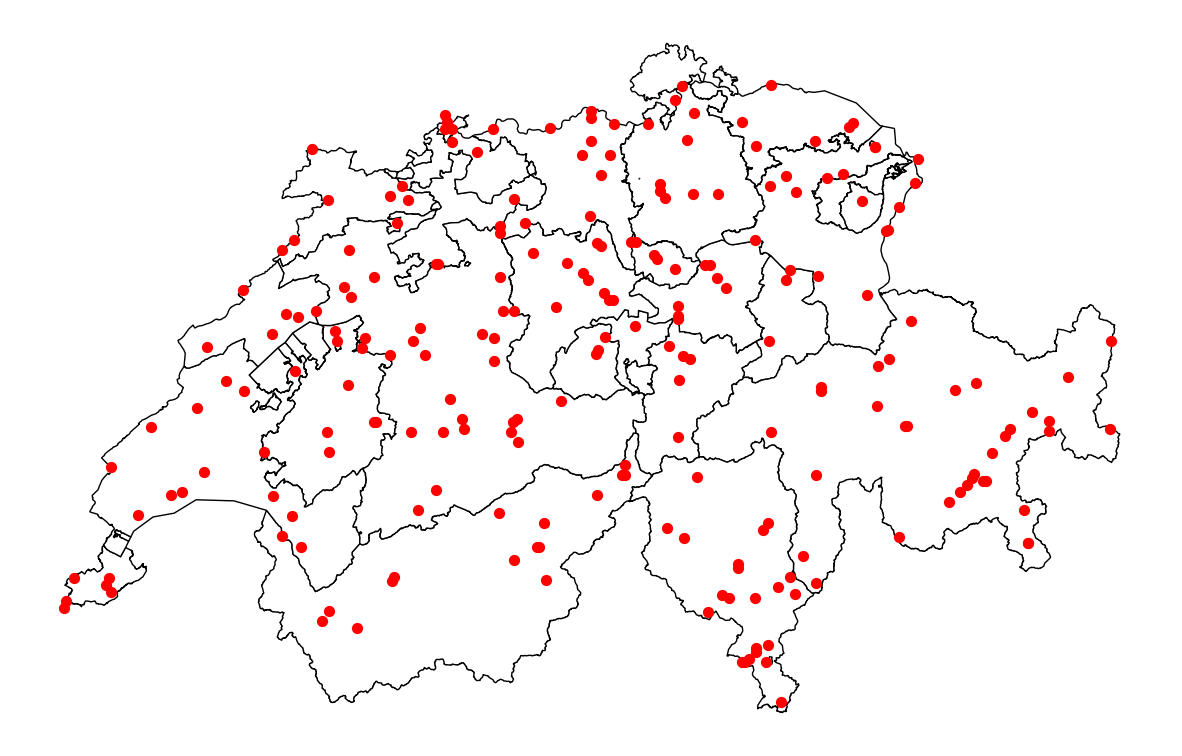

In [5]:
boundaries=gpd.read_file(r"..\data\swissboundaries3d_2026-01_2056_5728.gpkg\swissBOUNDARIES3D_1_5_LV95_LN02.gpkg", layer="tlm_kantonsgebiet") 
attributes_df=attributes_df[attributes_df["country"]=="CH"]
attributes_gdf=gpd.GeoDataFrame(attributes_df, geometry=gpd.points_from_xy(attributes_df["gauge_lon"], attributes_df["gauge_lat"]), crs=4326)

#Ensure both dataframes are in same projection
attributes_gdf=attributes_gdf.to_crs(2056)
boundaries=boundaries.to_crs(2056)

#Visualize
fig, ax = plt.subplots(figsize=(15, 16))

boundaries.plot(ax=ax, color="white", edgecolor="black")

attributes_gdf.plot(ax=ax, color="red", markersize=50)

ax.set_axis_off()
plt.show()

### 1.3 Select gauging stations of watershed Rhone

In [6]:
attributes_df[attributes_df["water_body_name"]=="Rhône"]

,gauge_id,country,gauge_name,water_body_name,id6,water_body_type,gauge_lon,gauge_lat,gauge_easting,gauge_northing,...,elev_min,elev_percentile10,elev_percentile25,elev_percentile50,elev_percentile75,elev_percentile90,elev_max,slope_mean,flat_area_perc,steep_area_perc
2,2009,CH,Porte_du_Scex,Rhône,RhoPor,stream,6.89,46.35,2557660,1133280,...,377.07,1015.99,1560.86,2191.36,2698.04,3103.99,4521.34,25.72,3.62,79.60
3,2011,CH,Sion,Rhône,RhoSio,stream,7.36,46.22,2593770,1118630,...,485.83,1209.13,1778.17,2379.66,2821.90,3208.04,4521.34,25.82,2.83,80.15
13,2024,CH,Branson,Rhône,RhoBra,stream,7.09,46.13,2573150,1108300,...,456.71,1119.07,1704.02,2323.10,2781.24,3171.12,4521.34,25.58,3.27,79.57
85,2174,CH,Chancy-Aux_Ripes,Rhône,RhoCha,stream,5.97,46.15,2486600,1112340,...,335.89,432.54,709.14,1464.81,2302.79,2864.01,4787.66,19.74,16.83,59.30
102,2217,CH,Chancy-Vers_Vaux,Rhône,RhoCVV,stream,5.96,46.13,2485440,1110040,...,329.87,432.08,696.37,1451.19,2293.60,2859.19,4787.66,19.61,17.02,58.85
210,2606,CH,Genève-Halle_de_l'ìle,Rhône,RhoGen,stream,6.14,46.20,2499890,1117850,...,367.12,416.65,749.42,1610.01,2437.17,2932.50,4521.34,20.21,16.95,61.12


### Check gauging station

In [7]:
hydro_df.columns
sion_gauge=hydro_df[hydro_df["gauge_id"]==2014]
sion_gauge.head(3)

,gauge_id,sign_start_date,sign_end_date,sign_number_of_years,q_mean,runoff_ratio,stream_elas,slope_fdc,baseflow_index_landson,hfd_mean,Q5,Q95,high_q_freq,high_q_dur,low_q_freq,low_q_dur,zero_q_freq
4,2014,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Branson gauging station- Rhone

In [9]:
branson_gauge_annual=pd.read_csv(r"..\data\timeseries\observation_based\CAMELS_CH_obs_based_2014.csv")
branson_gauge_annual["date"] = pd.to_datetime(branson_gauge_annual["date"])

branson_gauge_90 = branson_gauge_annual[branson_gauge_annual["date"] > "2010-01-01"]
branson_gauge_90.head(3)

,date,discharge_vol(m3/s),discharge_spec(mm/d),waterlevel(m),precipitation(mm/d),temperature_min(degC),temperature_mean(degC),temperature_max(degC),rel_sun_dur(%),swe(mm)
10593,2010-01-02,NaN,NaN,405.861,1.33,-12.41,-8.76,-5.59,1.12,45.0
10594,2010-01-03,NaN,NaN,405.824,0.00,-13.13,-10.05,-6.27,97.03,46.0
10595,2010-01-04,NaN,NaN,405.809,1.17,-11.14,-7.20,-5.24,0.74,46.0


#### Sion gauging station - Rhone

In [11]:
sion_gauge=hydro_df[hydro_df["gauge_id"]==2011]
sion_gauge_annual=pd.read_csv(r"..\data\timeseries\observation_based\CAMELS_CH_obs_based_2011.csv") # Javier
sion_gauge_annual["date"] = pd.to_datetime(sion_gauge_annual["date"])

sion_gauge_90 = sion_gauge_annual[sion_gauge_annual["date"] > "1990-01-01"]
sion_gauge_90.head(3)

,date,discharge_vol(m3/s),discharge_spec(mm/d),waterlevel(m),precipitation(mm/d),temperature_min(degC),temperature_mean(degC),temperature_max(degC),rel_sun_dur(%),swe(mm)
3288,1990-01-02,26.587,0.681,483.193,0.0,-10.33,-7.37,-3.37,99.19,NaN
3289,1990-01-03,36.718,0.941,483.359,0.0,-8.93,-6.45,-2.19,99.50,NaN
3290,1990-01-04,44.049,1.129,483.461,0.0,-10.36,-7.43,-2.88,99.74,NaN


#### Sion gauging station - Rhone - Daily discharge frequency diagram 1990-2020

<Axes: title={'center': 'Daily discharge [m3/s] at gauging station of Sion'}, xlabel='Date', ylabel='Discharge [m3/s] '>

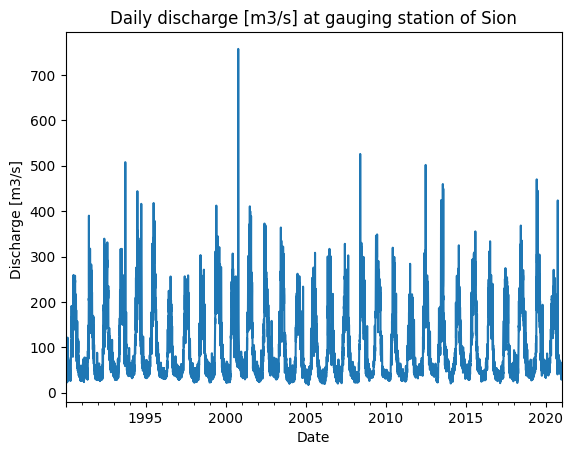

In [12]:
sion_gauge_90["date"] = pd.to_datetime(sion_gauge_90["date"]) # make date an datetimeobject
sion_gauge_90 = sion_gauge_90.set_index("date", drop=True) #set date as index

#Plot the discharge volume for all years
sion_gauge_90["discharge_vol(m3/s)"].plot(title="Daily discharge [m3/s] at gauging station of Sion", xlabel="Date", ylabel="Discharge [m3/s] ")


## 2. Frequency analysis

### 2.1 Check for stationarity

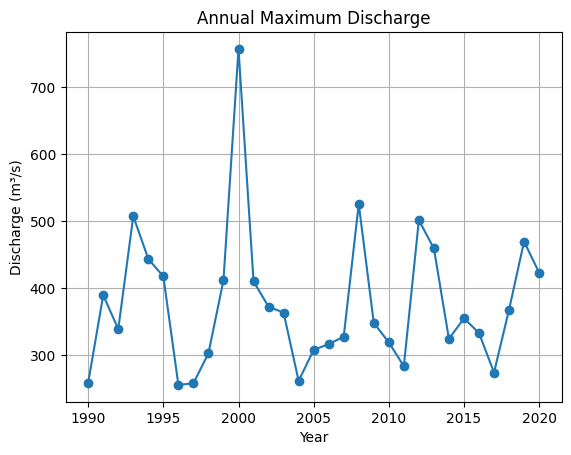

In [13]:
# Select annual maximum values
annual_max=sion_gauge_90["discharge_vol(m3/s)"].resample("YE").max()
annual_max = annual_max.dropna()

# Plot Annual maximum values and check visualyl for trend

plt.plot(annual_max.index.year, annual_max.values, marker="o")
plt.title("Annual Maximum Discharge")
plt.xlabel("Year")
plt.ylabel("Discharge (m³/s)")
plt.grid(True)
plt.show()

#### Check for significant trends using Mann-kendal test (non-linear)

In [14]:
result = mk.original_test(annual_max.values)
print(result)

# check for data period (30-50 years are good)
len(annual_max.dropna())

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.6833368087995224), z=np.float64(0.4079140071942694), Tau=np.float64(0.053763440860215055), s=np.float64(25.0), var_s=3461.6666666666665, slope=np.float64(0.7543750000000031), intercept=np.float64(344.0363749999999))


31

### 2.2 Fit parameters of distribution for extreme value analysis

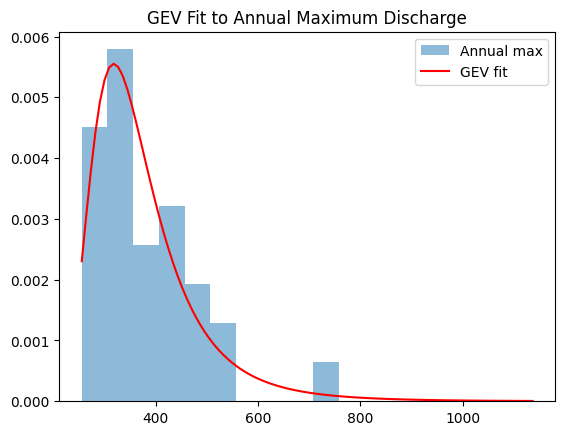

In [15]:
# Remove NA values and convert it to numpy array (.values)
data = annual_max.dropna().values

# Fit paramaters of distribution with gev.fit(), which uses the maximum-likelihood method
shape, loc, scale = gev.fit(data)

#compute 100 points for plotting
x = np.linspace(min(data), max(data)*1.5, 100)

# compute theoretical (model) probability density function
pdf = gev.pdf(x, shape, loc=loc, scale=scale)

# Plot
plt.hist(data, bins=10, density=True, alpha=0.5, label="Annual max")
plt.plot(x, pdf, "r-", label="GEV fit")

plt.legend()
plt.title("GEV Fit to Annual Maximum Discharge")
plt.show()

### 2.3 Check with goodness of fit test QQ-plot

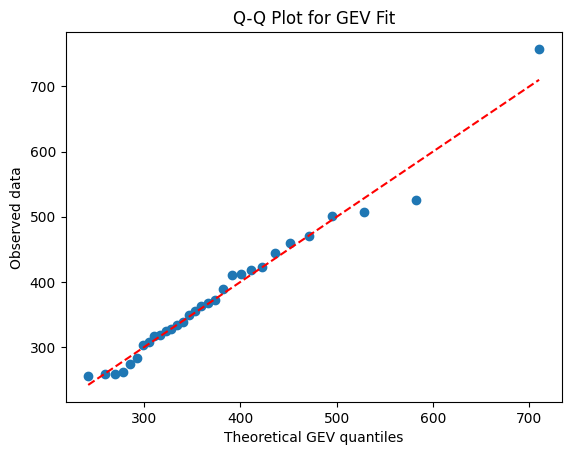

In [16]:
# empirical quantiles
sorted_data = np.sort(data)

# count number of observations
n = len(data)

#compute observed plotting positions
probs = (np.arange(1, n+1) - 0.5) / n

#compute theoretical plotting position
theoretical = gev.ppf(probs, shape, loc=loc, scale=scale)

#plot theoretical vs. observed values
plt.scatter(theoretical, sorted_data)

# Add reference line
plt.plot([min(theoretical), max(theoretical)],
         [min(theoretical), max(theoretical)],
         'r--')

plt.xlabel("Theoretical GEV quantiles")
plt.ylabel("Observed data")
plt.title("Q-Q Plot for GEV Fit")
plt.show()

### 2.4 Estimate flood magnitude

In [17]:
def return_level(T):
    p = 1 - 1/T
    return gev.ppf(p, shape, loc=loc, scale=scale)

# Define different return periods
HQ2 = round(return_level(2))
HQ10 = round(return_level(10))
HQ100 = round(return_level(100))

print("HQ2:", HQ2)
print("HQ10:", HQ10)
print("HQ100:", HQ100)

HQ2: 353
HQ10: 507
HQ100: 772


### 2.5 Include uncertainty with bootstrapping (takes 5min)

In [18]:
# normal confidence interval only makes sense when estimator is approximately normal and variance is known analytically
# For GEV return levels: usually NOT the case → bootstrap is safer

def bootstrap_all_return_levels(data, Ts, n_boot=3000):
    np.random.seed(42)

    n = len(data)
    boot = {T: np.empty(n_boot) for T in Ts}

    for i in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)

        c, loc_b, scale_b = gev.fit(sample)

        for T in Ts:
            p = 1 - 1/T
            boot[T][i] = gev.ppf(p, c, loc_b, scale_b)

    return {
        T: np.percentile(boot[T], [2.5, 50, 97.5])
        for T in Ts
    }

In [19]:
results = bootstrap_all_return_levels(data, Ts=[2, 10, 100], n_boot=3000)

ci_2 = results[2]
ci_10 = results[10]
ci_100 = results[100]

In [20]:
# structure: lower, median (best estimate), upper
print("HQ2  CI:", ci_2)
print("HQ10 CI:", ci_10)
print("HQ100 CI:", ci_100)

HQ2  CI: [256.64546709 327.44135595 405.65603182]
HQ10 CI: [4.35353817e+02 5.56120465e+02 2.84822521e+07]
HQ100 CI: [5.18092503e+02 1.07074234e+03 3.82196428e+15]


### 2.4 Return level plot (9min running)

In [21]:
Ts = np.logspace(np.log10(2), np.log10(100), 50)
results = bootstrap_all_return_levels(data, Ts, n_boot=3000)

In [22]:
lower = np.array([results[T][0] for T in Ts])
median = np.array([results[T][1] for T in Ts])
upper = np.array([results[T][2] for T in Ts])

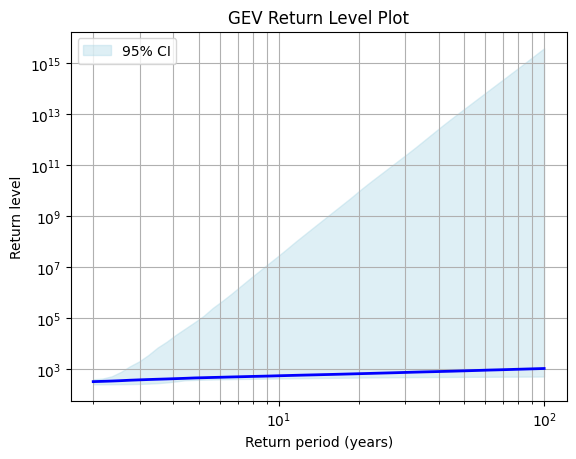

In [23]:
plt.plot(Ts, median, color='blue', lw=2)

plt.fill_between(
    Ts,
    lower,
    upper,
    color='lightblue',
    alpha=0.4,
    label='95% CI'
)

plt.xscale('log')
plt.yscale("log")
plt.xlabel('Return period (years)')
plt.ylabel('Return level')
plt.title('GEV Return Level Plot')
plt.grid(True, which='both')
plt.legend()
plt.show()

#### Plot return plot level

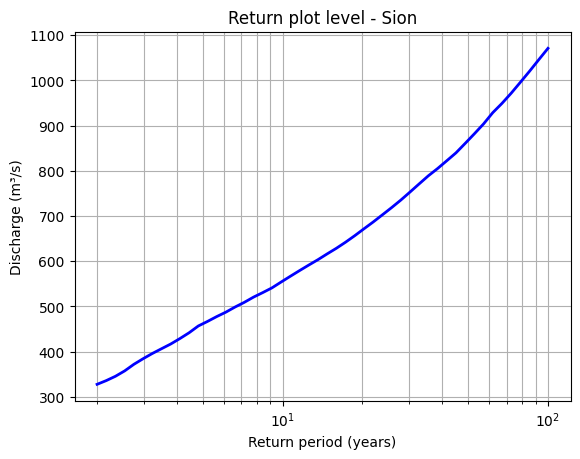

In [24]:
plt.plot(Ts, median, lw=2, color="blue")
plt.title("Return plot level - Sion")
plt.xscale("log")
plt.xlabel("Return period (years)")
plt.ylabel("Discharge (m³/s)")
plt.grid(True, which="both")

## 3. Time series analysis

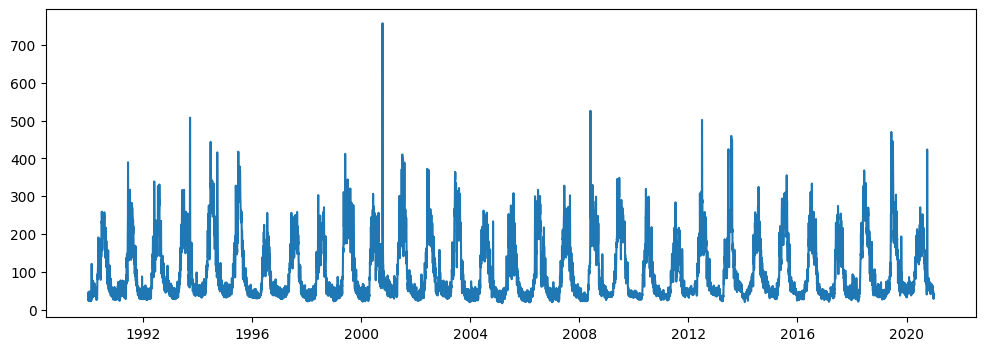

In [25]:
# sion_gauge_90.index is =sion_gauge_90.date (because date was set as index before
plt.figure(figsize=(12,4))
plt.plot(
    sion_gauge_90.index,   
    sion_gauge_90["discharge_vol(m3/s)"]
)
plt.show()

### 3.1 Time series- Removing non-stationarity

#### 3.1. Removing trends

#### 3.1.1 Check if significant trend

In [26]:
result = mk.original_test(sion_gauge_90["discharge_vol(m3/s)"])
print(result)

Mann_Kendall_Test(trend='decreasing', h=np.True_, p=np.float64(0.0015158118770162154), z=np.float64(-3.1716392289300055), Tau=np.float64(-0.01987460059133212), s=np.float64(-1273727.0), var_s=np.float64(161281467419.66666), slope=np.float64(-0.00033134955364957127), intercept=np.float64(66.47110414843338))


#### 3.1.2 Remove trend

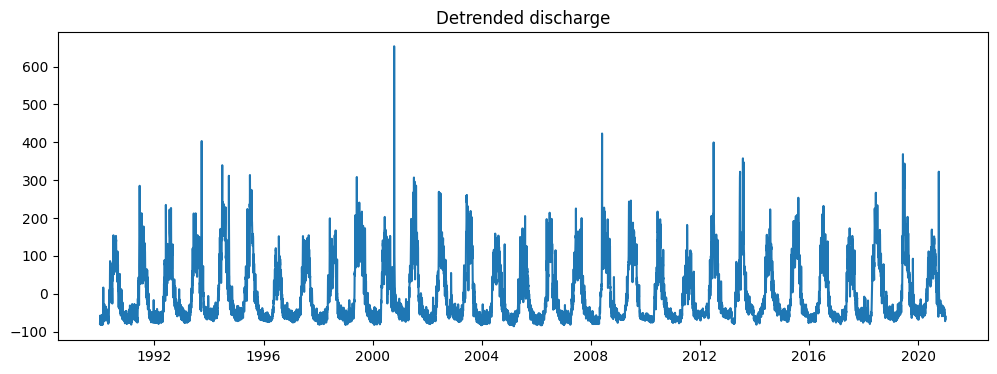

In [27]:
import numpy as np

# record y and xaxis
y = sion_gauge_90["discharge_vol(m3/s)"].values
t = np.arange(len(sion_gauge_90))

#compute slope
coef = np.polyfit(t, y, 1)   # slope + intercept
trend = np.polyval(coef, t)

#remove trend
sion_gauge_90["detrended"] = y - trend

#plot
plt.figure(figsize=(12,4))
plt.plot(sion_gauge_90.index, sion_gauge_90["detrended"])
plt.title("Detrended discharge")
plt.show()

#### 3.2 Removing seasonality

In [28]:
# Day of year
sion_gauge_90["doy"] = sion_gauge_90.index.dayofyear

# Seasonal mean and std for each day of year
seasonal_mean = (
    sion_gauge_90
    .groupby("doy")["discharge_vol(m3/s)"]
    .mean()
)

seasonal_std = (
    sion_gauge_90
    .groupby("doy")["discharge_vol(m3/s)"]
    .std()
)

# Map back to dataframe
sion_gauge_90["seasonal_mean"] = sion_gauge_90["doy"].map(seasonal_mean)
sion_gauge_90["seasonal_std"] = sion_gauge_90["doy"].map(seasonal_std)

# Deseasoned and standardized series
sion_gauge_90["discharge_stationary"] = (
    (sion_gauge_90["discharge_vol(m3/s)"] - sion_gauge_90["seasonal_mean"])
    / sion_gauge_90["seasonal_std"]
)

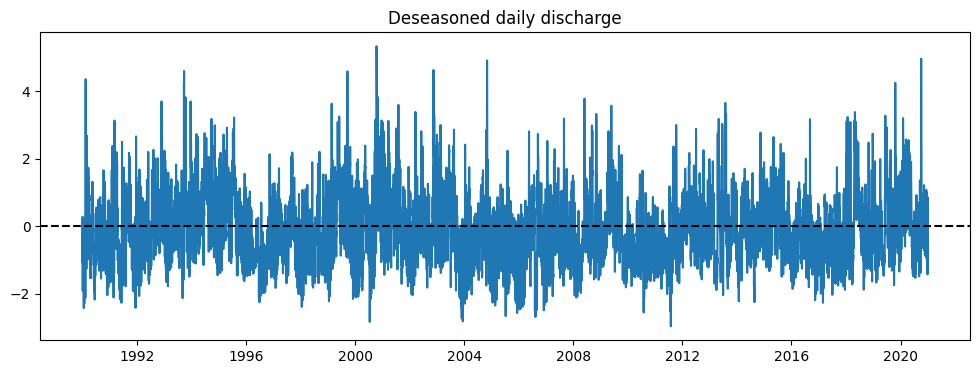

In [29]:
plt.figure(figsize=(12,4))
plt.plot(
    sion_gauge_90.index,
    sion_gauge_90["discharge_stationary"]
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Deseasoned daily discharge")
plt.show()

#### Check if removing periodicity worked

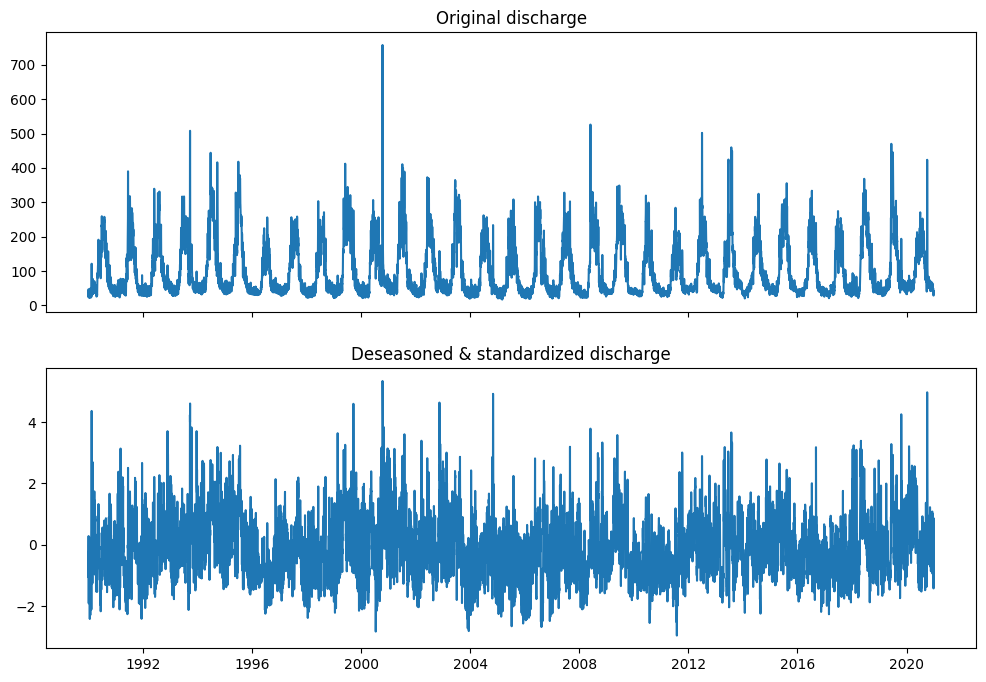

In [30]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(
    sion_gauge_90.index,
    sion_gauge_90["discharge_vol(m3/s)"]
)
ax[0].set_title("Original discharge")

ax[1].plot(
    sion_gauge_90.index,
    sion_gauge_90["discharge_stationary"]
)
ax[1].set_title("Deseasoned & standardized discharge")

plt.show()

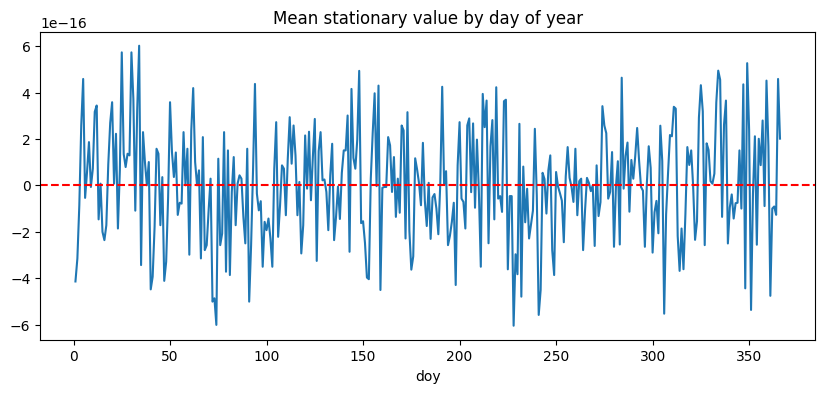

In [31]:
daily_mean_stationary = (
    sion_gauge_90
    .groupby("doy")["discharge_stationary"]
    .mean()
)

daily_mean_stationary.plot(figsize=(10,4))
plt.axhline(0, color="red", linestyle="--")
plt.title("Mean stationary value by day of year")
plt.show()

#### Check if stationarity was succesfully removed

In [32]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(
    sion_gauge_90["discharge_stationary"].dropna()
)

print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -10.51084200741047
p-value: 1.025500700300671e-18


### 3.2 Stochastic modelling

### 3.2.1 Check autocorrelation for model selection

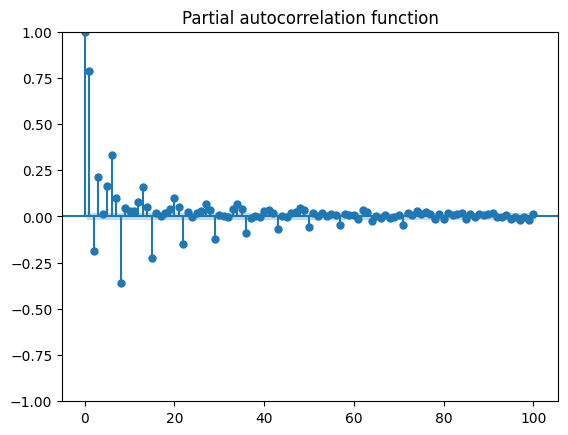

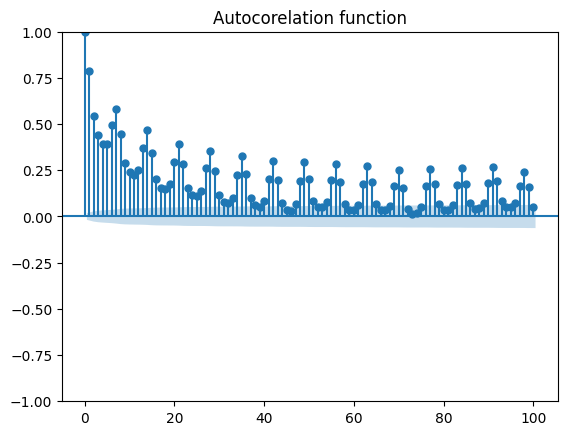

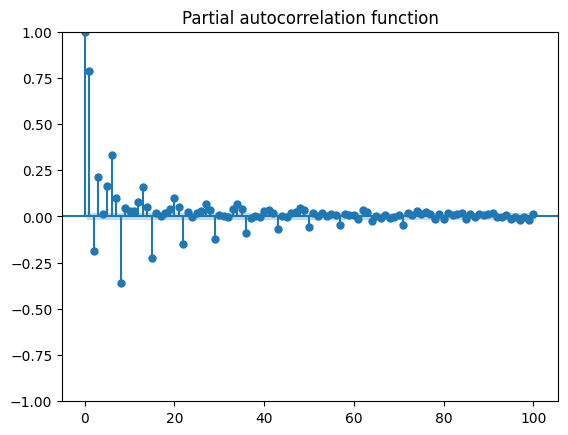

In [33]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(sion_gauge_90["discharge_stationary"].dropna(), lags=100, title="Autocorelation function")
plot_pacf(sion_gauge_90["discharge_stationary"].dropna(), lags=100, title="Partial autocorrelation function")

#### 3.2 check for weekly patterns

In [34]:
sion_gauge_90.groupby(
    sion_gauge_90.index.dayofweek
)["discharge_vol(m3/s)"].mean()

date
0    104.699605
1    108.816235
2    108.969402
3    108.260732
4    107.764535
5     95.676242
6     87.171223
Name: discharge_vol(m3/s), dtype: float64

##### Analyze differences weekend vs. working days => river regulation?

<Axes: xlabel='date', ylabel='discharge_vol(m3/s)'>

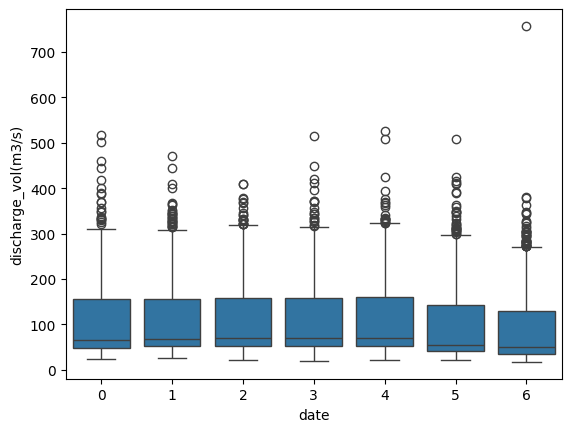

In [35]:
import seaborn as sns

sns.boxplot(
    x=sion_gauge_90.index.dayofweek,
    y=sion_gauge_90["discharge_vol(m3/s)"]
)

#### Select SARIMAX model with order, and seasonal order 

In [36]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
series = sion_gauge_90["discharge_stationary"].dropna()
model = SARIMAX(
    series,
    order=(2, 0, 1),
    seasonal_order=(1, 0, 1, 7)
)

results = model.fit()
print(results.summary())

c:\Users\Javier Feller\miniconda3\envs\stochastic_hydrology\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Javier Feller\miniconda3\envs\stochastic_hydrology\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Javier Feller\miniconda3\envs\stochastic_hydrology\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                     SARIMAX Results                                     
Dep. Variable:              discharge_stationary   No. Observations:                11322
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -7291.908
Date:                           Tue, 09 Jun 2026   AIC                          14595.816
Time:                                   21:34:48   BIC                          14639.823
Sample:                               01-02-1990   HQIC                         14610.620
                                    - 12-31-2020                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4690      0.045     10.324      0.000       0.380       0.558
ar.L2          0.2330      0.039      5.937

In [37]:
print(results.mle_retvals)

{'fopt': np.float64(0.6440476839409214), 'gopt': array([ 3.71525033e-07, -7.89457388e-07, -1.43585144e-07,  1.72784009e-07,
       -1.13986598e-07, -2.90882540e-05]), 'fcalls': 301, 'warnflag': 0, 'converged': True, 'iterations': 34}


##### Check ACF of residuals (Check model by analyzing residuals for nomraliaty and independence)

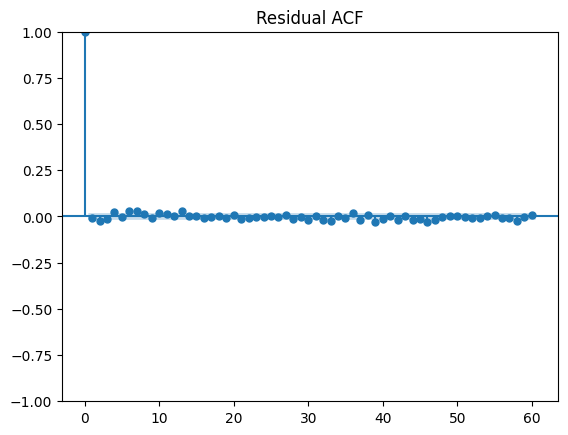

In [38]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(results.resid, lags=60)
plt.title("Residual ACF")
plt.show()

In [39]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(
    results.resid,
    lags=[7, 14, 21, 28, 35, 42],
    return_df=True
)

print(lb_test)

       lb_stat     lb_pvalue
7    37.957927  3.086494e-06
14   58.315197  2.311348e-07
21   63.123044  4.252887e-06
28   67.202043  4.534555e-05
35   85.055940  4.727882e-06
42  108.156613  9.597218e-08


## 4. Multivariate analysis (new method)

### 4.1. Extract annual max discharge AND same-day precipitation

In [40]:
# For each year, we find the DATE of the annual maximum discharge --> index
# First date need to be an index
sion_gauge_90["year"] = sion_gauge_90.index.year
annual_max_idx = sion_gauge_90.groupby("year")["discharge_vol(m3/s)"].idxmax()

events = sion_gauge_90.loc[annual_max_idx, ["discharge_vol(m3/s)", "precipitation(mm/d)"]].dropna()

print(f"Number of events: {len(events)}")
print(events.head())

Number of events: 31
            discharge_vol(m3/s)  precipitation(mm/d)
date                                                
1990-07-01              259.345                 0.12
1991-06-17              389.974                27.52
1992-06-02              339.267                36.70
1993-09-24              507.856                67.34
1994-06-27              443.931                 5.21


### 4.2. Check precipitation assumptions

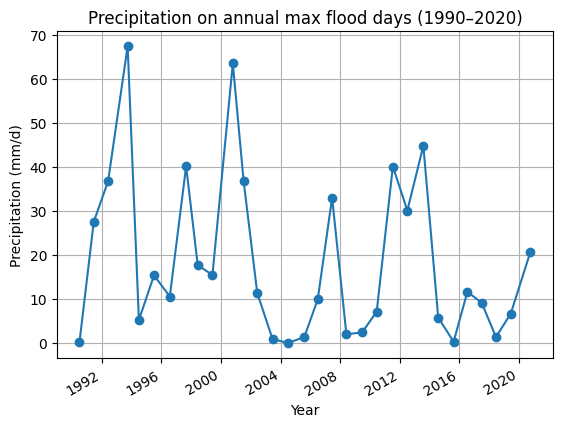

In [41]:
# Plot of raw data
events["precipitation(mm/d)"].plot(marker="o")
plt.title("Precipitation on annual max flood days (1990–2020)")
plt.ylabel("Precipitation (mm/d)")
plt.xlabel("Year")
plt.grid(True)
plt.savefig("plot1_scatter_1d:precip.png", dpi=300, bbox_inches='tight')
plt.show()

Looks fine. No obvious trend, values jump around randomly between years. The Mann-Kendall confirms: trend='no trend', p=0.31 — so stationary, good

In [42]:
# check for trends (Mann Kendell)
result_p = mk.original_test(events["precipitation(mm/d)"].values)
print(result_p)
# "no trend" like for discharge

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.30783043013369626), z=np.float64(-1.0197850179856736), Tau=np.float64(-0.13118279569892474), s=np.float64(-61.0), var_s=3461.6666666666665, slope=np.float64(-0.34777777777777774), intercept=np.float64(16.556666666666665))


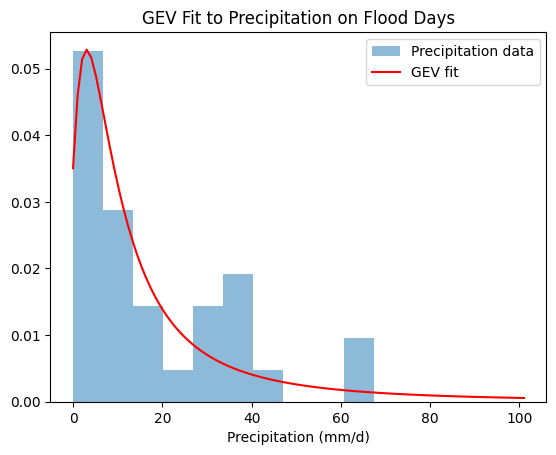

In [43]:
# Fit GEV and plot histogram + fit

p = events["precipitation(mm/d)"]
shape_p, loc_p, scale_p = gev.fit(p)

x = np.linspace(min(p), max(p)*1.5, 100)
pdf_p = gev.pdf(x, shape_p, loc=loc_p, scale=scale_p)

plt.hist(p, bins=10, density=True, alpha=0.5, label="Precipitation data")
plt.plot(x, pdf_p, "r-", label="GEV fit")
plt.legend()
plt.title("GEV Fit to Precipitation on Flood Days")
plt.xlabel("Precipitation (mm/d)")
plt.show()

The red curve doesn't follow the histogram very well. 
Most of the precip values are clustered near 0–20 mm, but the GEV is trying to fit a smooth curve that doesn't capture that spike at low values well

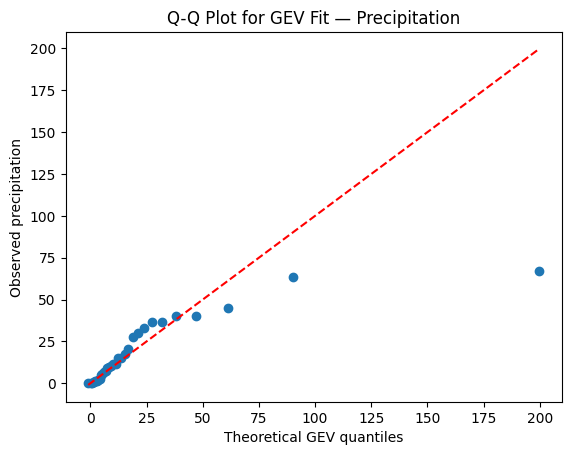

In [44]:
# QQplot to check the fit

sorted_p = np.sort(p)
n = len(p)
probs = (np.arange(1, n+1) - 0.5) / n
theoretical_p = gev.ppf(probs, shape_p, loc=loc_p, scale=scale_p)

plt.scatter(theoretical_p, sorted_p)
plt.plot([min(theoretical_p), max(theoretical_p)],
         [min(theoretical_p), max(theoretical_p)], 'r--')
plt.xlabel("Theoretical GEV quantiles")
plt.ylabel("Observed precipitation")
plt.title("Q-Q Plot for GEV Fit — Precipitation")
plt.show()

The points should follow the red dashed line closely. 
Instead they curve away significantly => especially the two outliers on the right (around 65–70 mm observed but the model predicts much higher). 
This means GEV is not a great fit for precipitation data

### 4.3. taking 3-day precipitation accumulation

In [45]:
# 3-day rolling sum of precipitation (current day + 2 days before)
sion_gauge_90["precip_3d"] = sion_gauge_90["precipitation(mm/d)"].rolling(3).sum()

# For each year, find the date of annual maximum discharge
sion_gauge_90["year"] = sion_gauge_90.index.year
annual_max_idx = sion_gauge_90.groupby("year")["discharge_vol(m3/s)"].idxmax()

# Grab discharge + 3-day precipitation on that date
events = sion_gauge_90.loc[annual_max_idx, ["discharge_vol(m3/s)", "precip_3d"]].dropna()

print(f"Number of flood events: {len(events)}")
print(events.head(10))

Number of flood events: 31
            discharge_vol(m3/s)  precip_3d
date                                      
1990-07-01              259.345      25.37
1991-06-17              389.974      85.80
1992-06-02              339.267      64.38
1993-09-24              507.856     148.85
1994-06-27              443.931      38.61
1995-07-03              417.919      33.61
1996-07-24              256.001      43.35
1997-08-28              258.449      44.63
1998-06-07              303.151      40.61
1999-06-03              412.151      26.03


### Checking assumptions (3d)

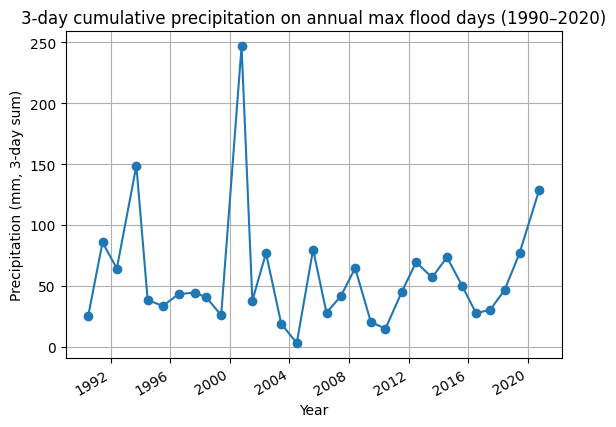

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.7084629632532715), z=np.float64(0.37392117326141366), Tau=np.float64(0.04946236559139785), s=np.float64(23.0), var_s=3461.6666666666665, slope=np.float64(0.23636363636363972), intercept=np.float64(41.08454545454541))


In [46]:
# Plot raw data
events["precip_3d"].plot(marker="o")
plt.title("3-day cumulative precipitation on annual max flood days (1990–2020)")
plt.ylabel("Precipitation (mm, 3-day sum)")
plt.xlabel("Year")
plt.grid(True)
plt.show()

# Mann-Kendall trend test
result_p = mk.original_test(events["precip_3d"].values)
print(result_p)
# If trend='no trend' → stationary → ok to fit distribution

GEV precipitation — shape: -0.210, loc: 37.1, scale: 24.3


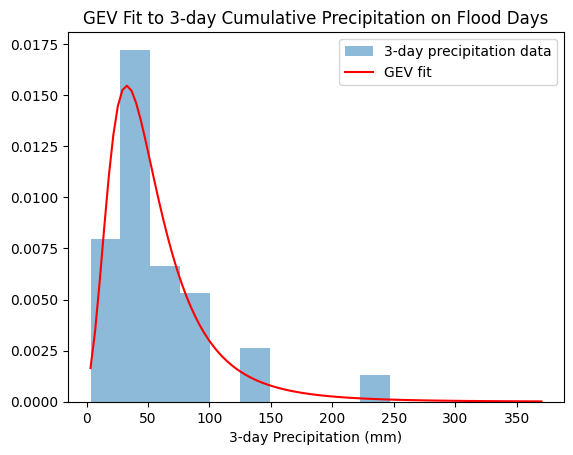

In [47]:
#  Fit GEV to 3-day precipitation & check goodness of fit


p = events["precip_3d"].values
shape_p, loc_p, scale_p = gev.fit(p)
print(f"GEV precipitation — shape: {shape_p:.3f}, loc: {loc_p:.1f}, scale: {scale_p:.1f}")

# Histogram + GEV fit
x = np.linspace(min(p), max(p)*1.5, 100)
pdf_p = gev.pdf(x, shape_p, loc=loc_p, scale=scale_p)

plt.hist(p, bins=10, density=True, alpha=0.5, label="3-day precipitation data")
plt.plot(x, pdf_p, "r-", label="GEV fit")
plt.legend()
plt.title("GEV Fit to 3-day Cumulative Precipitation on Flood Days")
plt.xlabel("3-day Precipitation (mm)")
plt.show()

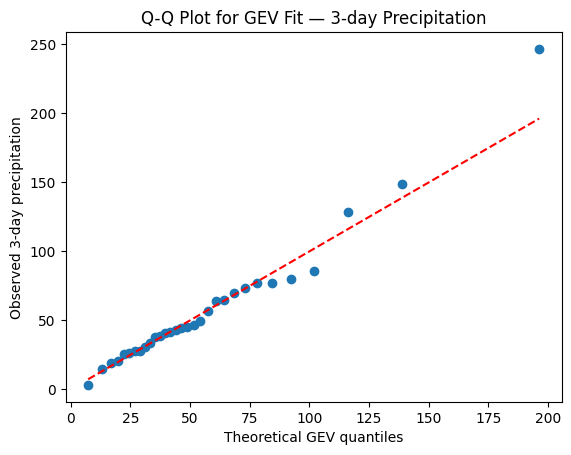

In [48]:
# QQ-plot to check fit
sorted_p = np.sort(p)
n = len(p)
probs = (np.arange(1, n+1) - 0.5) / n
theoretical_p = gev.ppf(probs, shape_p, loc=loc_p, scale=scale_p)

plt.scatter(theoretical_p, sorted_p)
plt.plot([min(theoretical_p), max(theoretical_p)],
         [min(theoretical_p), max(theoretical_p)], 'r--')
plt.xlabel("Theoretical GEV quantiles")
plt.ylabel("Observed 3-day precipitation")
plt.title("Q-Q Plot for GEV Fit — 3-day Precipitation")
plt.show()

The 3-day cumulative precipitation series showed no significant trend (Mann-Kendall: p=0.71), confirming stationarity. A GEV distribution was fitted to the precipitation series following the same approach as for discharge. The QQ-plot indicates a satisfactory fit, with minor deviation in the upper tail attributable to a single extreme event, which is expected given the small sample size of 31 annual maxima.

### 4.4. Fit distribution

In [49]:
q = events["discharge_vol(m3/s)"].values

# Reusing GEV parameters for discharge
shape_q, loc_q, scale_q = shape, loc, scale
print(f"GEV discharge (Javier) — shape: {shape_q:.3f}, loc: {loc_q:.1f}, scale: {scale_q:.1f}")
print(f"GEV precipitation      — shape: {shape_p:.3f}, loc: {loc_p:.1f}, scale: {scale_p:.1f}")


GEV discharge (Javier) — shape: -0.151, loc: 327.7, scale: 67.0
GEV precipitation      — shape: -0.210, loc: 37.1, scale: 24.3


Both have negative shape parameters, meaning both distributions have a finite upper bound

### Fit parameters of distribution

In [50]:
# problem : discharge is in m³/s and precipitation is in mm => convert both into probabilities between 0 and 1.
# u = "how extreme was this discharge compared to all years?"
# v = "how extreme was this 3-day precipitation compared to all years?"

u = gev.cdf(q, shape_q, loc=loc_q, scale=scale_q) # gev.cdf converts a raw value into a probability.
v = gev.cdf(p, shape_p, loc=loc_p, scale=scale_p)
# now we have 31 pairs of (u, v) values, all between 0 and 1

# Check dependence
rho, pval = spearmanr(u, v)
print(f"Spearman correlation: {rho:.3f} (p-value: {pval:.3f})")
print("(positive = big floods tend to happen after rainy days)")

Spearman correlation: 0.486 (p-value: 0.006)
(positive = big floods tend to happen after rainy days)


There is a statistically significant positive dependence between discharge and 3-day precipitation (p=0.006 is well below 0.05)
==> When 3-day precipitation is high, peak discharge tends to be high too

### 4.5. Fit Gumbel copula

Now we have 31 points in a square between 0 and 1. 
The copula is just a mathematical curve that describes how these points are distributed in that square.

The Gumbel copula specifically says: extreme u and extreme v tend to occur together — which matches the data (rho=0.486).

The copula gives one number called theta, like a  "dependence strength":

theta = 1 → no relationship at all & 
theta = 2 → moderate dependence & 
theta = 3+ → strong dependence

In [51]:
import subprocess
subprocess.run(["pip", "install", "pyvinecopulib"], capture_output=True)
import pyvinecopulib as pv

obs = np.column_stack([u, v])
cop = pv.Bicop(family=pv.BicopFamily.gumbel)
cop.fit(obs)

theta = cop.parameters[0][0]
print(f"Gumbel copula theta = {theta:.3f}")
print("(theta=1 = independence, higher = stronger dependence)")

Gumbel copula theta = 1.588
(theta=1 = independence, higher = stronger dependence)


RESULT: Theta = 1.588 => above 1 (independence), confirming there is a relationship between discharge and precipitation. 

It's small-moderate, so other factors influence and have impacts => makes kind of sense for an Alpine catchment where snowmelt also plays a role independently of rainfall.

### 4.6. Plots of Copulas

#### Scatter of pseudo-observations

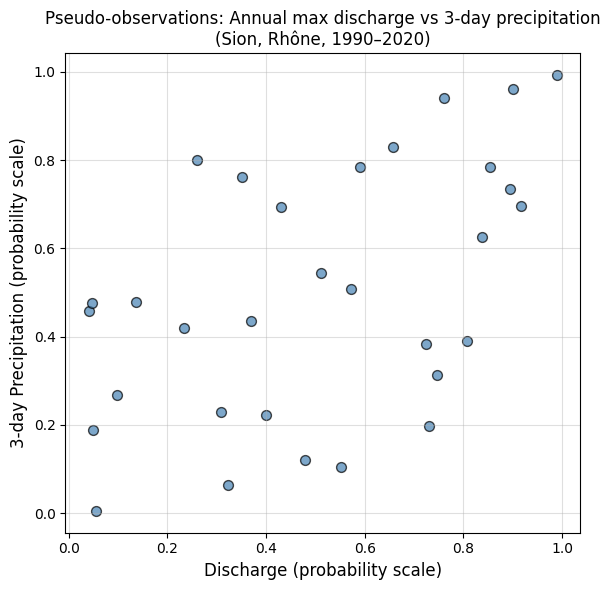

In [52]:
# PLOT 1

plt.figure(figsize=(6, 6))
plt.scatter(u, v, alpha=0.7, edgecolors='k', color='steelblue', s=50)
plt.xlabel("Discharge (probability scale)", fontsize=12)
plt.ylabel("3-day Precipitation (probability scale)", fontsize=12)
plt.title("Pseudo-observations: Annual max discharge vs 3-day precipitation\n(Sion, Rhône, 1990–2020)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Each dot = 1 year. On x-axis is how extreme the discharge was (0=lowest & 1=highest) & on y-axis is shown how extreme the 3-day precipitation was. For instance fots in the top-right corner mean years with both high discharge and high precipitation. Reminder: Spearman correlation was 0.486.

No real trend is visible, maybe only a really really weak positive trend. 


#### Plot of copula density

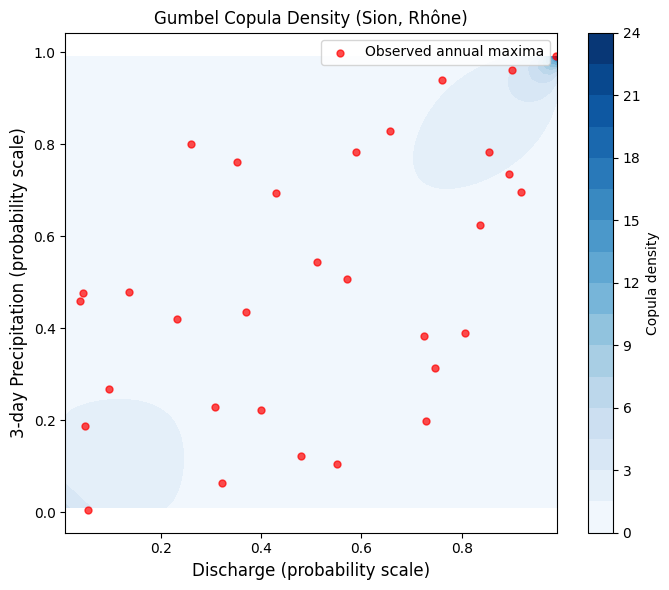

In [53]:
# PLOT 2

grid_n = 80
x_grid = np.linspace(0.01, 0.99, grid_n)
y_grid = np.linspace(0.01, 0.99, grid_n)        # This creates a grid of 6400 points covering every combination of (u, v) between 0 and 1.
xx, yy = np.meshgrid(x_grid, y_grid)
grid_pts = np.column_stack([xx.ravel(), yy.ravel()])

density = cop.pdf(grid_pts).reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(7, 6))
cf = ax.contourf(xx, yy, density, levels=20, cmap="Blues")
plt.colorbar(cf, ax=ax, label="Copula density")
ax.scatter(u, v, color='red', s=25, alpha=0.7, label="Observed annual maxima")
ax.set_xlabel("Discharge (probability scale)", fontsize=12)
ax.set_ylabel("3-day Precipitation (probability scale)", fontsize=12)
ax.set_title("Gumbel Copula Density (Sion, Rhône)")
ax.legend()
plt.tight_layout()
plt.show()

The blue shading shows where the Gumbel copula puts most of its "weight". We can see concentration in the bottom-left (both variables low —> normal years) and top-right (both variables extreme —> compound flood events). 

#### Plot of Joint return periods contour

 here we are computing the return period at every point on a grid, then drewing lines connecting points with equal return period

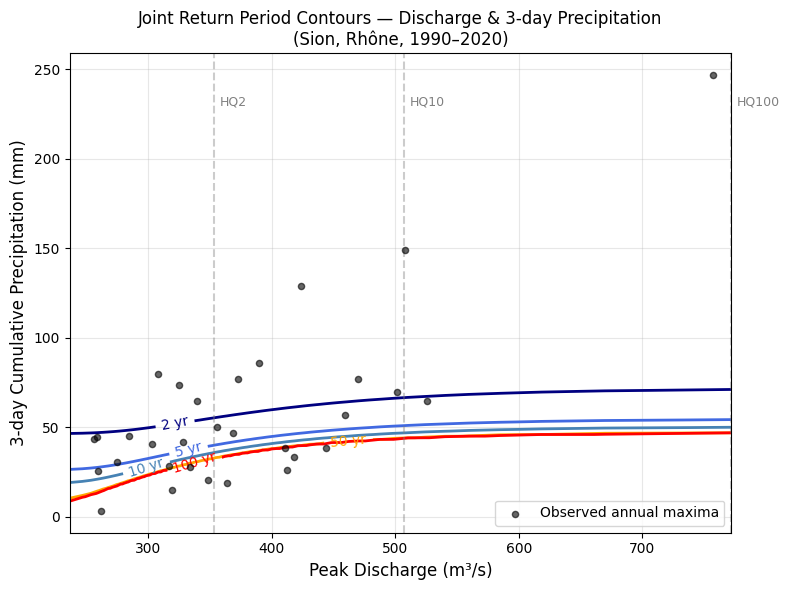

In [54]:
# PLOT 3

cop_cdf = cop.cdf(grid_pts).reshape(grid_n, grid_n) # what's the joint probability at each point? => C(u,v) — the probability that BOTH variables are below those thresholds simultaneously.
joint_exceed = (1 - xx) - (1 - yy) + cop_cdf        # Joint exceedance probability => converts "probability both are below" into "probability both are above"
joint_exceed = np.maximum(joint_exceed, 1e-6)       # P(Q > q AND P > p) = 1 - P(Q ≤ q) - P(P ≤ p) + P(Q ≤ q AND P ≤ p) = (1 - u) - (1 - v) + C(u,v)
joint_rp = 1 / joint_exceed

# Convert back to real units
q_axis = gev.ppf(x_grid, shape_q, loc=loc_q, scale=scale_q)
p_axis = gev.ppf(y_grid, shape_p, loc=loc_p, scale=scale_p)
qq_real, pp_real = np.meshgrid(q_axis, p_axis)

fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contour(qq_real, pp_real, joint_rp,             # draws lines connecting all points with the same value 
                levels=[2, 5, 10, 50, 100],
                colors=['navy', 'royalblue', 'steelblue', 'orange', 'red'],
                linewidths=2)
ax.clabel(cs, fmt="%d yr", fontsize=10)
ax.scatter(q, p, color='black', s=20, alpha=0.6, zorder=5, label="Observed annual maxima")

# Javier's return level thresholds for reference
for hq_val, hq_name in [(353, "HQ2"), (507, "HQ10"), (772, "HQ100")]:
    ax.axvline(hq_val, linestyle='--', alpha=0.4, color='gray')
    ax.text(hq_val + 5, max(p) * 0.93, hq_name, fontsize=9, color='gray')

ax.set_xlabel("Peak Discharge (m³/s)", fontsize=12)
ax.set_ylabel("3-day Cumulative Precipitation (mm)", fontsize=12)
ax.set_title("Joint Return Period Contours — Discharge & 3-day Precipitation\n(Sion, Rhône, 1990–2020)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Plot: The curves show combinations of discharge + precipitation that have the same joint return period. For example, the 10-year contour line means that any combination of discharge and precipitation on that curve happens together once every 10 years on average.

The contour lines are almost horizontal, this means that the joint return period is mostly driven by discharge and not precipitation. => adding more precipitation won't change the discharge much.

#### Comparison table

In [55]:
# Comparison table: univariate vs joint 

print("=" * 60)
print(f"{'Event':<10} {'Univariate RP':>15} {'Joint RP':>15}")
print("=" * 60)

p_median = np.median(p)
v_median = gev.cdf(p_median, shape_p, loc=loc_p, scale=scale_p)

for hq_val, hq_name, uni_rp in [(353, "HQ2", 2), (507, "HQ10", 10), (772, "HQ100", 100)]:
    u_t = gev.cdf(hq_val, shape_q, loc=loc_q, scale=scale_q)
    jp = 1 - u_t - v_median + cop.cdf(np.array([[u_t, v_median]]))[0]
    jp = max(jp, 1e-9)
    joint_rp_val = 1 / jp
    print(f"{hq_name:<10} {uni_rp:>15} yr {joint_rp_val:>13.0f} yr")

print("=" * 60)
print("\nJoint RP > univariate RP = compound events are rarer")
print("than looking at discharge alone suggests.")

Event        Univariate RP        Joint RP
HQ2                      2 yr             3 yr
HQ10                    10 yr            11 yr
HQ100                  100 yr           102 yr

Joint RP > univariate RP = compound events are rarer
than looking at discharge alone suggests.


=> the dependence between discharge and precipitation at Sion is relatively weak 